# Regularization

Regularization is a umbrella term that refers to approaches that help reduce the chance of overfitting, usually either by normalization or through added penatlies.

### 1. Ridge regression ($L_2$ regularization)

Perhaps the most common form of regularization is known as *ridge regression* or $L_2$ *regularization*, sometimes also called *Tikhonov regularization*. This proceeds by penalizing the sum of squares (2-norms) of the model coefficients; in this case, the penalty on the model fit would be 

$$ J(\theta) =  \frac{1}{2}\sum_{i=1}^m(h_\theta(x^{(i)}) - y^{(i)})^2 + \lambda\sum_{j=1}^n \boldsymbol{\theta}_j^2$$

where $\lambda$ is a free parameter that controls the strength of the penalty.

### 2. Lasso regression ($L_1$ regularization)

Another very common type of regularization is known as lasso, and involves penalizing the sum of absolute values (1-norms) of regression coefficients:

$$ J(\theta) = \frac{1}{2}\sum_{i=1}^m(h_\theta(x^{(i)}) - y^{(i)})^2+ \lambda\sum_{j=1}^n |\theta_j|$$

Though this is conceptually very similar to ridge regression, the results can differ surprisingly: that is, lasso regression can set certain features to zero, while ridge regression focuses on shrinking all parameters so it is not overly reliant on one feature.

### 3. Elastic net 

When you lack domain knowledge, you can simply use elastic net.

$$
J(\theta) = \frac{1}{2}\sum_{i=1}^m(h_\theta(x^{(i)}) - y^{(i)})^2 + \lambda \sum_{j=1}^n |\theta_j| + (1 - \lambda) \sum_{k=1}^n \theta_k^2
$$



### Ridge or Lasso or Elastic net??

Regularization should be ALMOST ALWAYS used, since these techniques reduces overfitting.

How to choose is a little bit difficult. It is easier to understand the assumptions behind.
1.  Ridge assumes that coefficients are normally distributed.   **Thus, if you don't want any feature to dominate too much, use Ridge.**
2. Lasso assumes that coefficients are Laplace distributed (in layman sense, it mean some predictors are very useful while some are completely irrelevant).   Here, Lasso has the ability to shrink coefficient to zero thus eliminate predictors that are not useful to the output, thus automatic feature selection.  **In simple words, if you have only very few predictors with medium/large effect, use Lasso.**
3.  Elastic basically is a compromise between the two, and thus take huge computation time to reach that compromise.  **If you have the resource to spare, you can use Elastic net**


## Code

In [1]:
#experiment tracking
import mlflow
import os
# This the dockerized method.
# We build two docker containers, one for python/jupyter and another for mlflow.
# The url `mlflow` is resolved into another container within the same composer.
mlflow.set_tracking_uri("http://localhost:9000")
# In the dockerized way, the user who runs this code will be `root`.
# The MLflow will also log the run user_id as `root`.
# To change that, we need to set this environ["LOGNAME"] to your name.
os.environ["LOGNAME"] = "sushmi"
# mlflow.create_experiment(name="chaky-diabetes-example")  #create if you haven't create
mlflow.set_experiment(experiment_name="sushmi-regularization-example")

2025/11/15 22:50:00 INFO mlflow.tracking.fluent: Experiment with name 'sushmi-regularization-example' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/754793093138811852', creation_time=1763221800575, experiment_id='754793093138811852', last_update_time=1763221800575, lifecycle_stage='active', name='sushmi-regularization-example', tags={}>

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [16]:
df = pd.read_csv("../datasets/Cars.csv")
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [17]:
# Defining a mapping of values to numerical encodings
encoding_map = {
    'First Owner': 1,
    'Second Owner': 2,
    'Third Owner': 3,
    'Fourth & Above Owner': 4,
    'Test Drive Car': 5
}

# Encoding the labels in the column 'owner'
df['owner'] = df['owner'].map(encoding_map)

In [18]:
# Saving the values to remove in a array
values_to_remove=['CNG','LPG']
# Reoving the rows with the specified values and reflecting it in the dataframe
df =df[~df['fuel'].isin(values_to_remove)]

In [19]:
# Removing the kmph frpm the records in the column mileage using split such that only the first part of the string is taken while the second part i.e. the kmph (unit) is discarded
df['mileage']=df['mileage'].str.split().str[0]

In [21]:
# Converting the data type of mileage feature to float from string
df['mileage']=df['mileage'].astype(float)

In [23]:
# Removing the CC frpm the records in the column engine using split such that only the first part of the string is taken while the second part i.e. the CC (unit) is discarded
df['engine']= df.engine.str.split().str[0]
# Converting the type of mileage column to float from object (string)
df['engine']=df['engine'].astype(float)

In [25]:
# Removing the bhp frpm the records in the column max_power using split such that only the first part of the string is taken while the second part i.e. thebhp (unit) is discarded
df['max_power']=df.max_power.str.split().str[0]

# Converting max_power to float
df['max_power']=df['max_power'].astype('float')

## Veryfying the type of the column max_power aka power
df['max_power'].dtypes

dtype('float64')

In [28]:
# Renaming and replacing the columns according to convenience
df.rename(columns ={
    'name':'brand'
}, inplace=True)
# Splitting the brand feature and only taking the first part
df['brand']= df.brand.str.split().str[0]
#Veryfying the ouput
df['brand'].head()

0     Maruti
1      Skoda
2      Honda
3    Hyundai
4     Maruti
Name: brand, dtype: object

In [29]:
# Removing the column torque using the drop column function
df=df.drop(['torque'],axis=1)

In [30]:
# Using the query method of data frame which makes a copy from the original dataframe with the query (where owner is not 5 i.e. Test Drive Car) as string and saving it to our dataframe
df=df.query('owner != 5')

In [31]:
# Resetting the index to prepare for our one hot encoding of the brand (name) column
df.reset_index(inplace=True)

In [32]:

from sklearn.preprocessing import OneHotEncoder
"""
        One-hot encodes a categorical feature in a DataFrame.

    Parameters:
    - encoder (OneHotEncoder): The OneHotEncoder object fitted on the training data.
    - dataframe (DataFrame): The DataFrame containing the feature to be one-hot encoded.
    - feature (str): The name of the categorical feature to be encoded.

    Returns:
    - DataFrame: A new DataFrame with the specified feature one-hot encoded and the original feature dropped.
    """

# Create function for one-hot encoding a feature in dataframe 
def one_hot_transform(encoder, dataframe, feature):
    # Use the encoder to transform the specified feature
    encoded = encoder.transform(dataframe[[feature]])

    # Extract the category labels for the feature
    categories = encoder.categories_[0]
    # Create a DataFrame with one-hot encoded columns and category labels as column names
    feature_df = pd.DataFrame(encoded.toarray(), columns=categories[1:])
    # Concatenate the original DataFrame and the one-hot encoded DataFrame
    concat_dataframe = pd.concat([dataframe, feature_df], axis=1)
    # Drop the original feature from the resulting DataFrame
    return concat_dataframe.drop(feature, axis=1)
    

In [33]:
# Since 'brand' has multiple value and to prevent the ordinality that comes with it, one-hot encoding is applied to it
brand_ohe = OneHotEncoder(drop='first').fit(df[['brand']])
df = one_hot_transform(brand_ohe, df, 'brand')

In [34]:
from sklearn.preprocessing import LabelEncoder

# Initializing the LabelEncoder
label_encoder_fuel = LabelEncoder()
label_encoder_transmission = LabelEncoder()
label_encoder_seller_type = LabelEncoder()

# Fitting and transforming the the required column
df['fuel'] = label_encoder_fuel.fit_transform(df['fuel'])
df['transmission'] = label_encoder_transmission.fit_transform(df['transmission'])
df['seller_type'] = label_encoder_seller_type.fit_transform(df['seller_type'])

In [35]:
# Dropping thr column index
df.drop(columns='index', inplace=True)
df

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,...,Mitsubishi,Nissan,Opel,Peugeot,Renault,Skoda,Tata,Toyota,Volkswagen,Volvo
0,2014,450000,145500,0,1,1,1,23.40,1248.0,74.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2014,370000,120000,0,1,1,2,21.14,1498.0,103.52,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,2006,158000,140000,1,1,1,3,17.70,1497.0,78.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2010,225000,127000,0,1,1,1,23.00,1396.0,90.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2007,130000,120000,1,1,1,1,16.10,1298.0,88.20,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8023,2013,320000,110000,1,1,1,1,18.50,1197.0,82.85,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8024,2007,135000,119000,0,1,1,4,16.80,1493.0,110.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8025,2009,382000,120000,0,1,1,1,19.30,1248.0,73.90,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8026,2013,290000,25000,0,1,1,1,23.57,1396.0,70.00,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [36]:
# Excluding one-hot encoded columns
selected_cols = ['year', 'selling_price', 'km_driven', 'fuel', 'transmission', 'owner', 'mileage', 'engine', 'max_power', 'seats']
dfcopy = df.copy()
dfcopy = df[selected_cols]

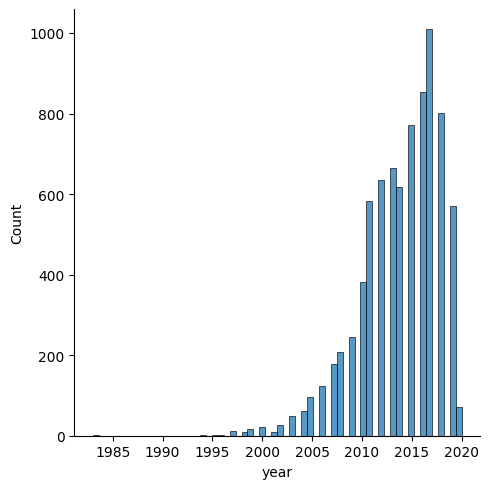

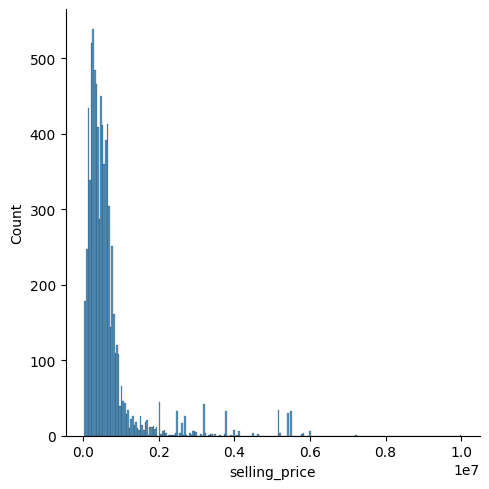

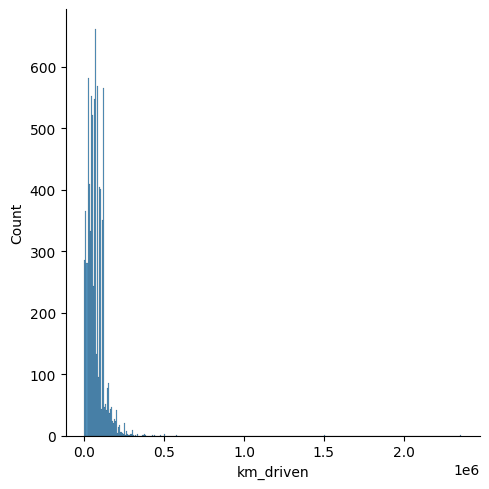

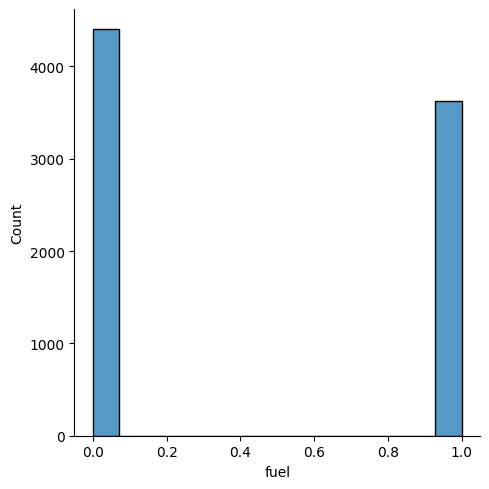

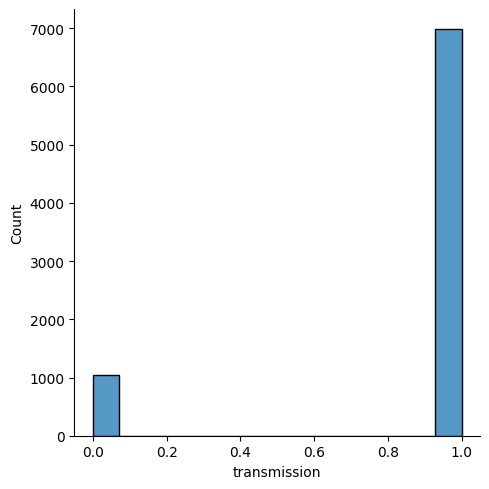

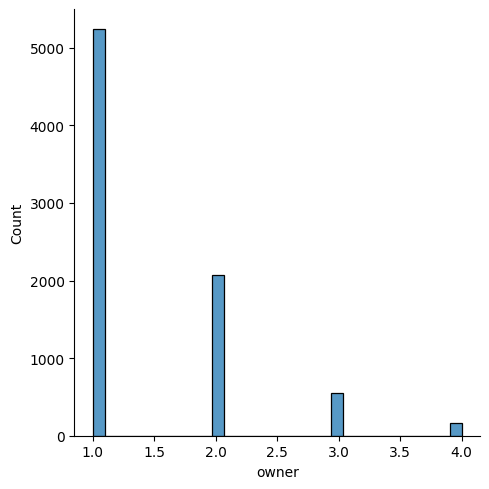

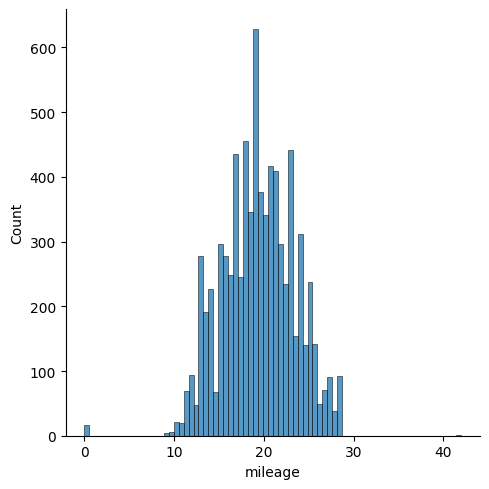

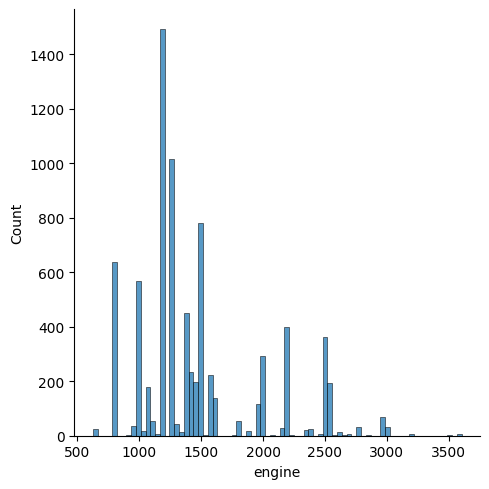

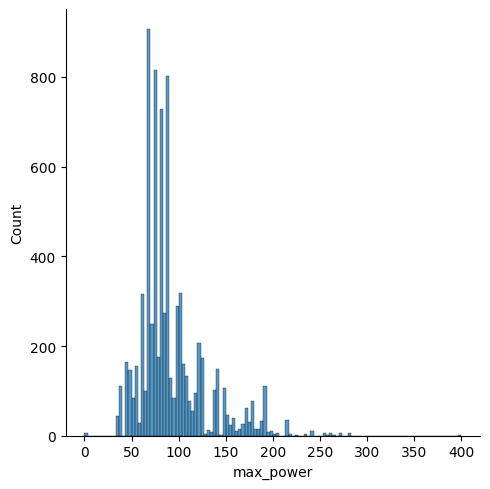

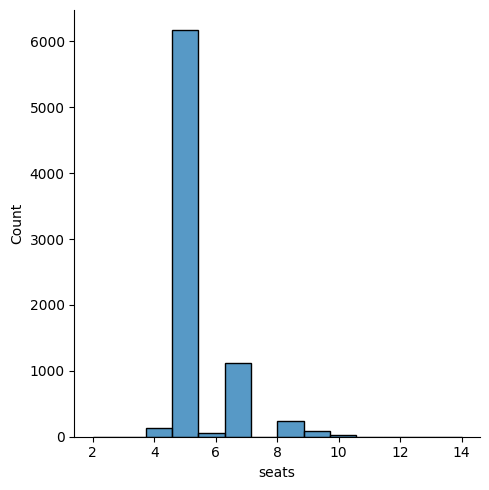

In [37]:
# Using the distribution plot to get the count of all the numeric features except selling_price
for col in dfcopy.columns:
    sns.displot(dfcopy, x=df[col])

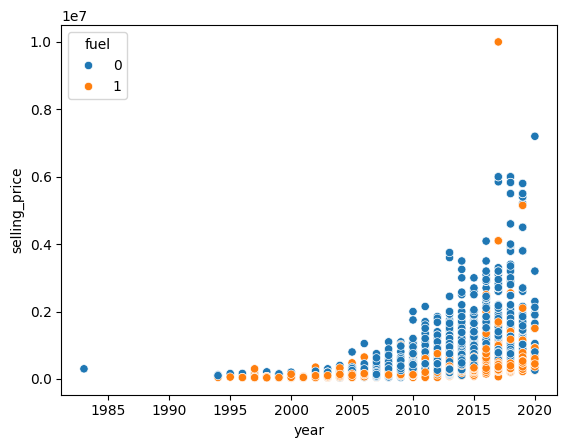

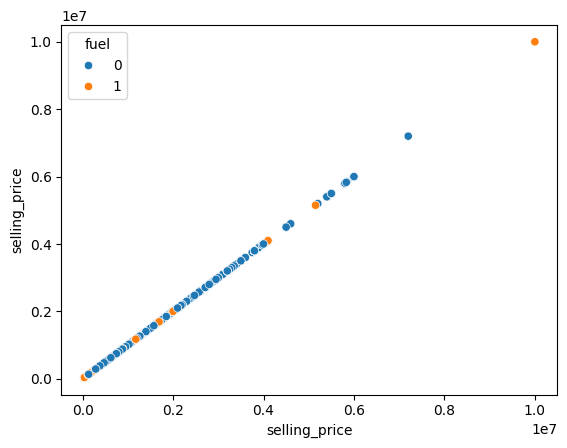

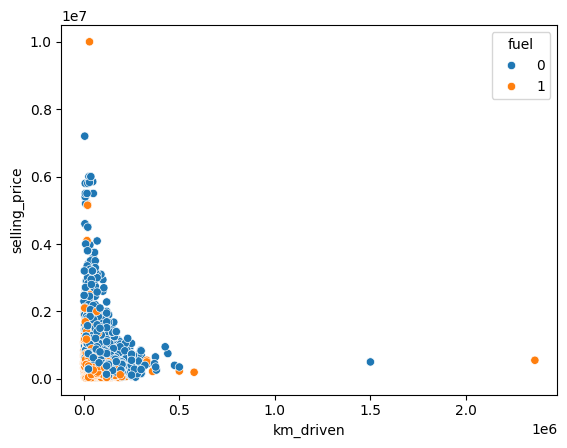

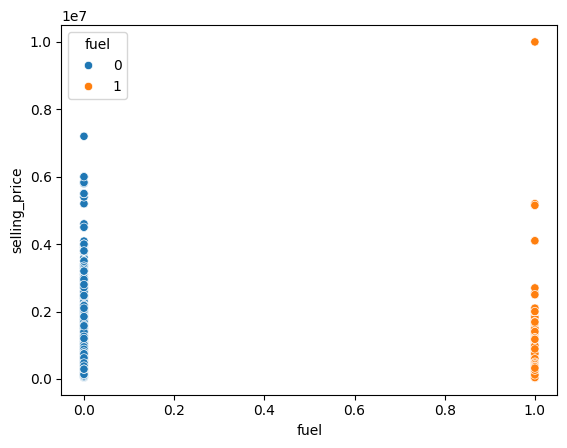

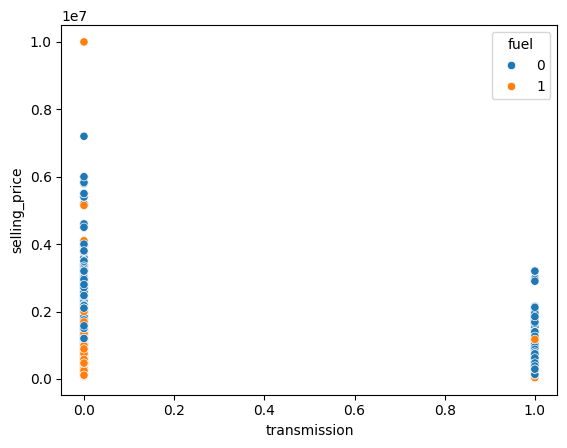

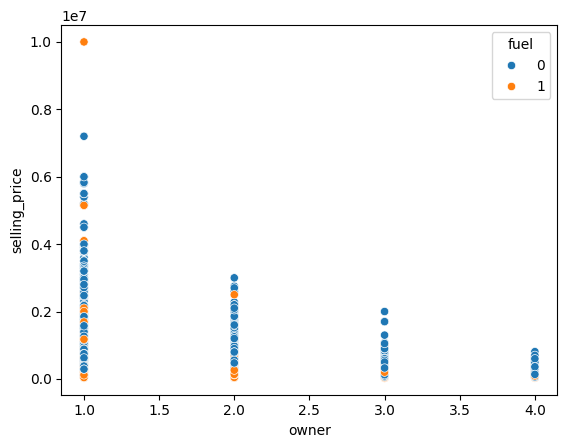

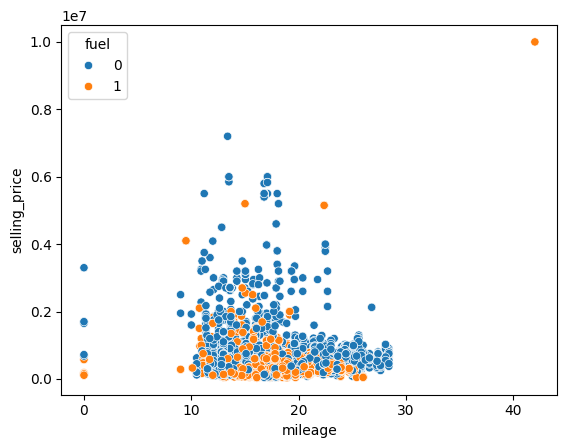

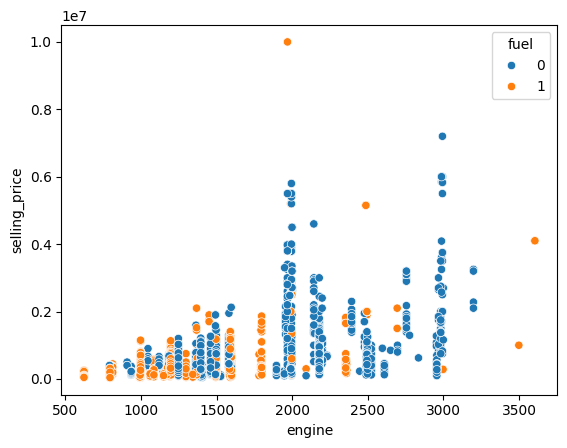

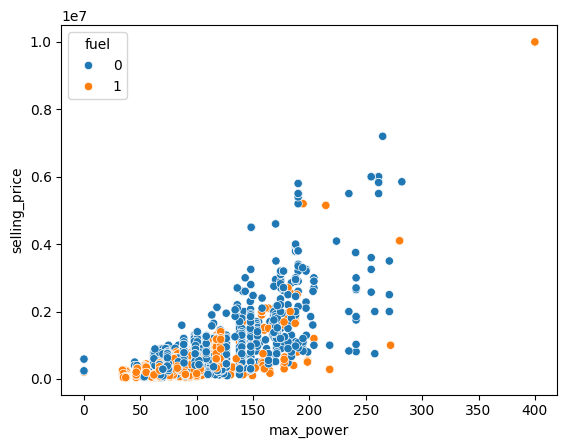

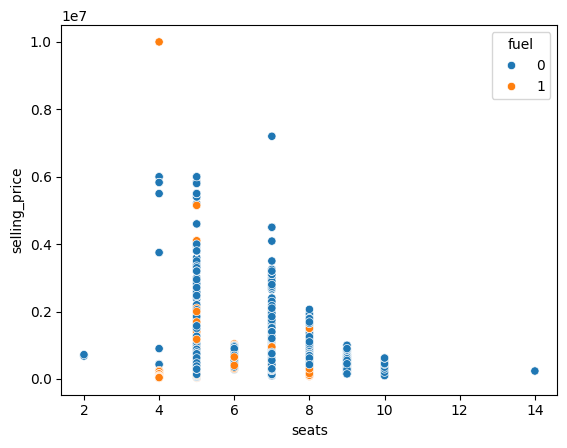

In [38]:
# PLotting the continuous features in the scatter plot against selling_price with fuel as the hue
for col in dfcopy.columns:    
    sns.scatterplot(x=dfcopy[col], y=df['selling_price'], hue=df['fuel'])
    plt.show()

<Axes: >

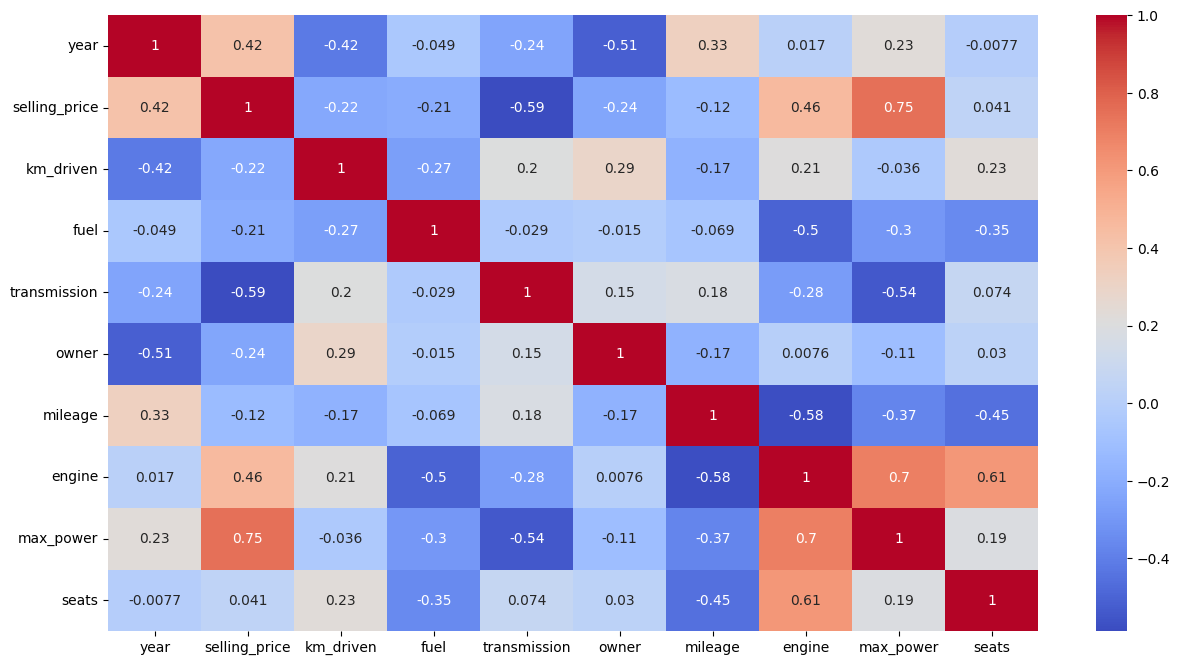

In [39]:
#Correlation matrix to see the correlation between the features
plt.figure(figsize = (15,8))
sns.heatmap(dfcopy.corr(numeric_only=True), annot=True, cmap="coolwarm")

<Axes: xlabel='x', ylabel='y'>

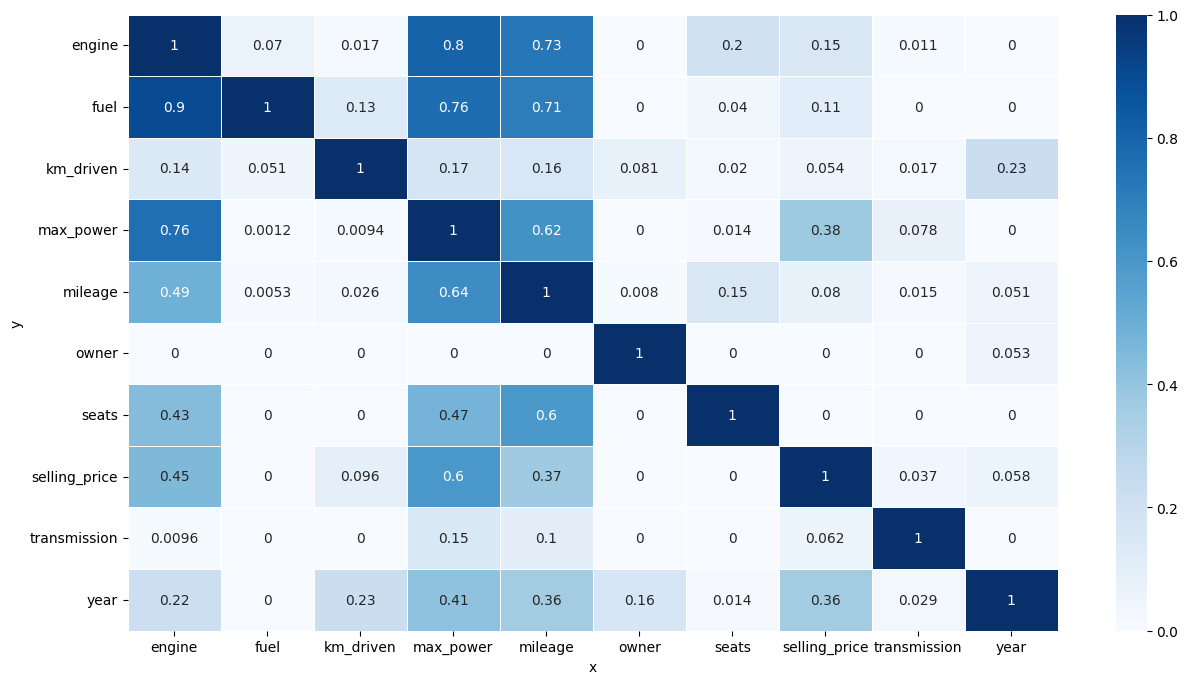

In [40]:
# Predictive power score of features using correlation values
import ppscore as pps

matrix_df = pps.matrix(dfcopy)[['x', 'y', 'ppscore']].pivot(columns='x', index='y', values='ppscore')

plt.figure(figsize = (15,8))
sns.heatmap(matrix_df, vmin=0, vmax=1, cmap="Blues", linewidths=0.5, annot=True)

# Data Processing

In [ ]:
brand_categories = list(brand_ohe.categories_[0][1:])
# Independent variables, or X or features or predictors or explanatory variables
# taking significant features based on PSS values >= 0.10 (rounding to 2 decimal places)
selected_features_cols = ['engine', 'km_driven', 'max_power', 'mileage'] + brand_categories
X = df[selected_features_cols]
y = np.log(df['selling_price'])

In [57]:
# Train Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [59]:
# Check null values in X_train
null_train = X_train.isna().sum()
null_train[null_train > 0]

engine       171
max_power    165
mileage      171
dtype: int64

In [60]:
y_train.isna().sum()

np.int64(0)

Mean of max_power: 91.8197257033248
Median of max_power: 82.4


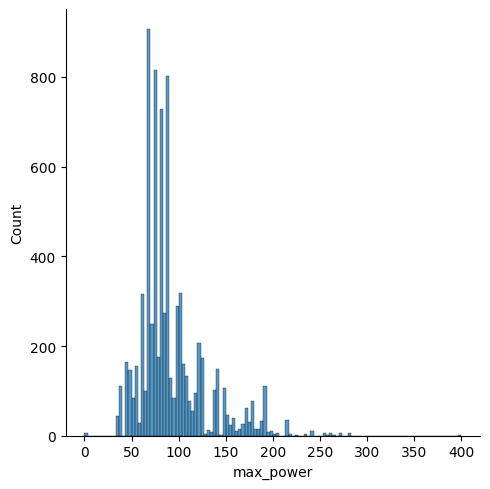

In [61]:
# Filling null values for max_power
# Let's inspect the distribution plot, mean and median of max_power again
sns.displot(data=df, x='max_power')

print(f"Mean of max_power: {df['max_power'].mean()}")
print(f"Median of max_power: {df['max_power'].median()}")

In [62]:
# max_power distribution is skewed so missing values are substituted with median
X_train['max_power'].fillna(X_train['max_power'].median(), inplace=True)
X_test['max_power'].fillna(X_train['max_power'].median(), inplace=True)

Mean of mileage: 19.391961863322244
Median of mileage: 19.3


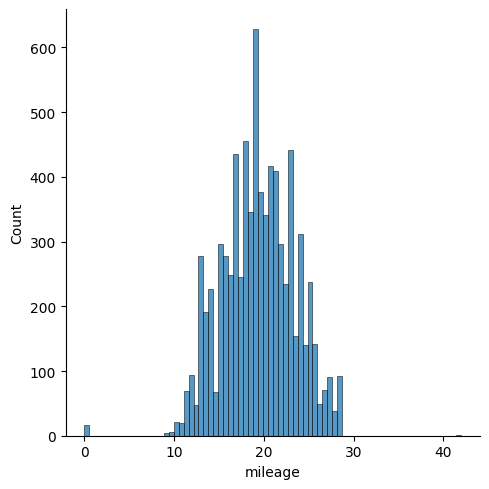

In [63]:
# Let's inspect the distribution plot, mean and median of mileage
sns.displot(data=df, x='mileage')

print(f"Mean of mileage: {df['mileage'].mean()}")
print(f"Median of mileage: {df['mileage'].median()}")

In [64]:
# mileage distribution is approximately normal so missing values are substituted with mean
X_train['mileage'].fillna(X_train['mileage'].mean(), inplace=True)
X_test['mileage'].fillna(X_train['mileage'].mean(), inplace=True)

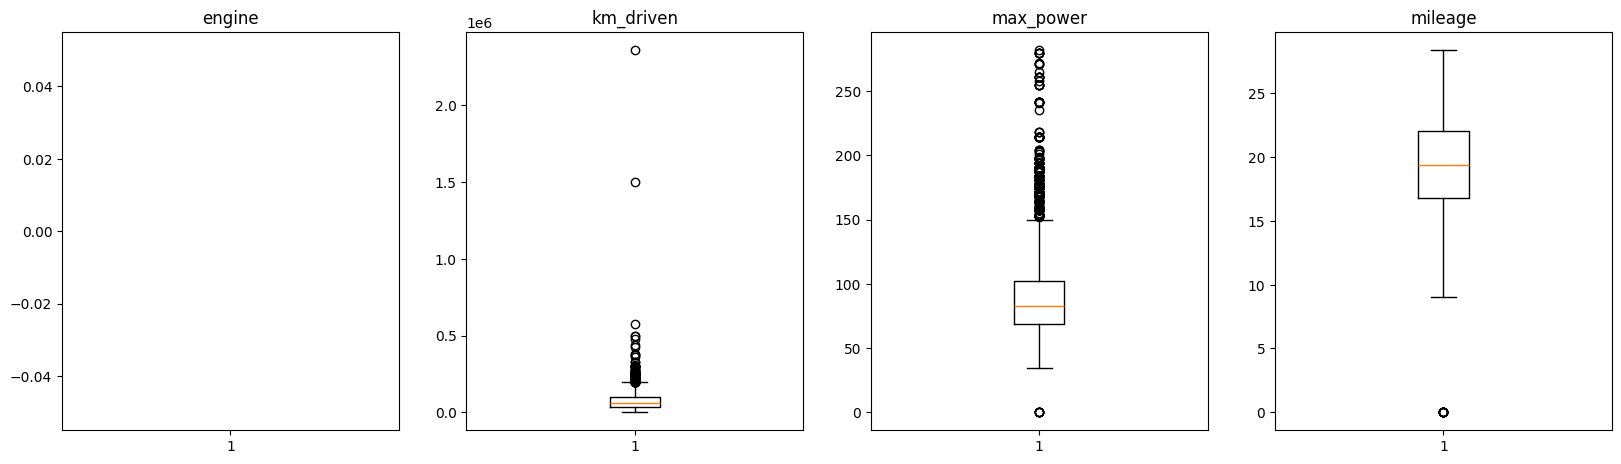

In [ ]:
# Checking outliers
# Create a dictionary of columns.
#col_dict = {'max_power': 1,'year': 2, 'mileage':3}
col_dict = {'engine': 1, 'km_driven': 2, 'max_power': 3, 'mileage': 4}

# Detect outliers in each variable using box plots.
plt.figure(figsize=(20,30))

for variable,i in col_dict.items():
                     plt.subplot(5,4,i)
                     plt.boxplot(X_train[variable])
                     plt.title(variable)

plt.show()

In [66]:
def outlier_count(col, data = X_train):
    
    # calculate your 25% quatile and 75% quatile
    q75, q25 = np.percentile(data[col], [75, 25])
    
    # calculate your inter quatile
    iqr = q75 - q25
    
    # min_val and max_val
    min_val = q25 - (iqr*1.5)
    max_val = q75 + (iqr*1.5)
    
    # count number of outliers, which are the data that are less than min_val or more than max_val calculated above
    outlier_count = len(np.where((data[col] > max_val) | (data[col] < min_val))[0])
    
    # calculate the percentage of the outliers
    outlier_percent = round(outlier_count/len(data[col])*100, 2)
    
    if(outlier_count > 0):
        print("\n"+15*'-' + col + 15*'-'+"\n")
        print('Number of outliers: {}'.format(outlier_count))
        print('Percent of data that is outlier: {}%'.format(outlier_percent))

In [67]:
for col in X_train[['km_driven', 'max_power','mileage']]:
    outlier_count(col)


---------------km_driven---------------

Number of outliers: 119
Percent of data that is outlier: 1.85%

---------------max_power---------------

Number of outliers: 459
Percent of data that is outlier: 7.15%

---------------mileage---------------

Number of outliers: 16
Percent of data that is outlier: 0.25%


The outliers are less than 10% , we are ignoring it and processing to scaling

In [68]:
# Scaling : distribution plots are skewed - Normalization done using min/max scaling

from sklearn.preprocessing import MinMaxScaler

# Define a list of numerical feature names that need to be scaled
num_cols = ['km_driven', 'max_power', 'mileage']

# Create a MinMaxScaler to scale features to a specified range (0 to 1)
scaler = MinMaxScaler(feature_range=(0, 1))

# Scale the numerical features in the training dataset (X_train)
# 1. Compute the scaling parameters (minimum and maximum values) based on the training data
# 2. Apply the scaling transformation to the specified columns in X_train
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])

# Scale the same numerical features in the test dataset (X_test)
# 1. Use the scaling parameters learned from the training data to transform X_test
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [69]:
# Let's check shapes of all X_train, X_test, y_train, y_test
print("Shape of X_train: ", X_train.shape)
print("Shape of X_test: ", X_test.shape)
print("Shape of y_train: ", y_train.shape)
print("Shape of y_test: ", y_test.shape)

Shape of X_train:  (6422, 35)
Shape of X_test:  (1606, 35)
Shape of y_train:  (6422,)
Shape of y_test:  (1606,)


In [84]:
from sklearn.model_selection import KFold

class LinearRegression(object):
    
    #in this class, we add cross validation as well for some spicy code....
    kfold = KFold(n_splits=3)

    """
    Linear Regression model with gradient descent optimization and regularization.
    Supports batch, stochastic, and mini-batch gradient descent methods.
    """
    def __init__(self, regularization, lr=0.001, method='batch', init_method= 'xavier', use_momentum=True, momentum= 0.5, num_epochs=500, batch_size=50, cv=kfold):
        """
        Initialize the LinearRegression model.

        Parameters:
        - regularization: Regularization method (e.g., L1, L2)
        - lr: Learning rate for gradient descent
        - method: Optimization method ('batch', 'sto' for stochastic, 'mini' for mini-batch)
        - init_method: Weight initialization method ('xavier' else 'zero') default is 'xavier'
        - use_momentum: Use momentum in gradient descent (True or False) default is True
        - momentum: Momentum coefficient (default is 0.5)
        - num_epochs: Number of training epochs
        - batch_size: Size of mini-batches (for 'mini' method)
        - cv: Cross-validation method (default is 3-fold cross-validation)
        """
        self.regularization = regularization
        self.lr         = lr
        self.method     = method
        self.init_method = init_method
        self.num_epochs = num_epochs
        self.batch_size = batch_size
        self.cv         = cv
        print(f"""Initialized LinearRegression with {type(self.regularization).__name__} regularization, 
              lr={self.lr}, 
              method={self.method}, 
              init_method={self.init_method}, 
              num_epochs={self.num_epochs}, 
              batch_size={self.batch_size},
              cv={self.cv.n_splits} folds.""") 
        

    def mse(self, ytrue, ypred):
        return ((ytrue, ypred) ** 2).sum() / ytrue.shape[0]
    
    def r2_score(self, ytrue, ypred):
        ss_res = ((ytrue - ypred) ** 2).sum()
        ss_tot = ((ytrue - ytrue.mean()) ** 2).sum()
        return 1 - (ss_res / ss_tot)
    
    def xavier_init(self, dataset):
        size = dataset.shape[0]
        #calculate the range for the weights
        random_weights = np.random.rand(dataset.shape[1])
        #scale them using lower and upper bounds
        lower, upper = -(1.0/np.sqrt(size)), 1.0/np.sqrt(size)
        scaled_weights = lower + random_weights * (upper - lower)
        return scaled_weights
    
    def fit(self, X_train, y_train):            
        #create a list of kfold scores
        self.kfold_scores = list()
        
        #reset val loss
        self.val_loss_old = np.inf

        #kfold.split in the sklearn.....
        #5 splits
        for fold, (train_idx, val_idx) in enumerate(self.cv.split(X_train)):
            
            X_cross_train = X_train[train_idx]
            y_cross_train = y_train[train_idx]
            X_cross_val   = X_train[val_idx]
            y_cross_val   = y_train[val_idx]

            if self.init_method == 'xavier':
                self.theta = self.xavier_init(X_cross_train)
            else:
                self.theta = np.zeros(X_cross_train.shape[1]) # zero initialization if not xavier
            
            #define X_cross_train as only a subset of the data
            #how big is this subset?  => mini-batch size ==> 50
            
            #one epoch will exhaust the WHOLE training set
            with mlflow.start_run(run_name=f"Fold-{fold}", nested=True):
                
                params = {"method": self.method, "lr": self.lr, "reg": type(self).__name__}
                mlflow.log_params(params=params)
                
                for epoch in range(self.num_epochs):
                
                    #with replacement or no replacement
                    #with replacement means just randomize
                    #with no replacement means 0:50, 51:100, 101:150, ......300:323
                    #shuffle your index
                    perm = np.random.permutation(X_cross_train.shape[0])
                            
                    X_cross_train = X_cross_train[perm]
                    y_cross_train = y_cross_train[perm]
                    
                    if self.method == 'sto':
                        for batch_idx in range(X_cross_train.shape[0]):
                            X_method_train = X_cross_train[batch_idx].reshape(1, -1) #(11,) ==> (1, 11) ==> (m, n)
                            y_method_train = y_cross_train[batch_idx] 
                            train_loss = self._train(X_method_train, y_method_train)
                    elif self.method == 'mini':
                        for batch_idx in range(0, X_cross_train.shape[0], self.batch_size):
                            #batch_idx = 0, 50, 100, 150
                            X_method_train = X_cross_train[batch_idx:batch_idx+self.batch_size, :]
                            y_method_train = y_cross_train[batch_idx:batch_idx+self.batch_size]
                            train_loss = self._train(X_method_train, y_method_train)
                    else:
                        X_method_train = X_cross_train
                        y_method_train = y_cross_train
                        train_loss = self._train(X_method_train, y_method_train)

                    mlflow.log_metric(key="train_loss", value=train_loss, step=epoch)

                    yhat_val = self.predict(X_cross_val)
                    val_loss_new = self.mse(y_cross_val, yhat_val)
                    mlflow.log_metric(key="val_loss", value=val_loss_new, step=epoch)
                    
                    #early stopping
                    if np.allclose(val_loss_new, self.val_loss_old):
                        break
                    self.val_loss_old = val_loss_new
            
                self.kfold_scores.append(val_loss_new)
                print(f"Fold {fold}: {val_loss_new}")
            
                    
    def _train(self, X, y):
        yhat = self.predict(X)
        m    = X.shape[0]        

        if self.regularization:
            grad = (1/m) * X.T @(yhat - y) + self.regularization.derivation(self.theta)
        else:
            grad = (1/m) * X.T @(yhat - y)

        if hasattr(self, 'use_momentum') and self.use_momentum:
            # If momentum is enabled, apply momentum to the gradient descent update
            # Calculate the update step based on the gradient
            self.step = self.lr * grad
             #Update the model's weights with momentum
            # The momentum term helps smooth out the gradient updates and accelerate convergence
            self.theta = self.theta - self.step + self.momentum * self.prev_step
            # Update the previous step with the current step for the next iteration#
            self.prev_step = self.step
        else:    
            self.theta = self.theta - self.lr * grad

        return self.mse(y, yhat)
    
    def predict(self, X):
        return X @ self.theta  #===>(m, n) @ (n, )
    
    def _coef(self):
        return self.theta[1:]  #remind that theta is (w0, w1, w2, w3, w4.....wn)
                               #w0 is the bias or the intercept
                               #w1....wn are the weights / coefficients / theta
    def _bias(self):
        return self.theta[0]
    

Now we can create `Ridge`, `Lasso` and `Elastic` class that extends the `LinearRegression`, with added penalty.

In [85]:
class LassoPenalty:
    
    def __init__(self, l):
        self.l = l # lambda value
        
    def __call__(self, theta): #__call__ allows us to call class as method
        return self.l * np.sum(np.abs(theta))
        
    def derivation(self, theta):
        return self.l * np.sign(theta)
    
class RidgePenalty:
    
    def __init__(self, l):
        self.l = l
        
    def __call__(self, theta): #__call__ allows us to call class as method
        return self.l * np.sum(np.square(theta))
        
    def derivation(self, theta):
        return self.l * 2 * theta
    
class ElasticPenalty:
    
    def __init__(self, l = 0.1, l_ratio = 0.5):
        self.l = l 
        self.l_ratio = l_ratio

    def __call__(self, theta):  #__call__ allows us to call class as method
        l1_contribution = self.l_ratio * self.l * np.sum(np.abs(theta))
        l2_contribution = (1 - self.l_ratio) * self.l * 0.5 * np.sum(np.square(theta))
        return (l1_contribution + l2_contribution)

    def derivation(self, theta):
        l1_derivation = self.l * self.l_ratio * np.sign(theta)
        l2_derivation = self.l * (1 - self.l_ratio) * theta
        return (l1_derivation + l2_derivation)
    
class Lasso(LinearRegression):
    
    def __init__(self, method, lr, l, init_method= 'xavier', use_momentum=True, momentum= 0.5):
        self.regularization = LassoPenalty(l)
        super().__init__(self.regularization, lr, method, init_method, use_momentum, momentum)
        
class Ridge(LinearRegression):
    
    def __init__(self, method, lr, l, init_method= 'xavier', use_momentum=True, momentum= 0.5):
        self.regularization = RidgePenalty(l)
        super().__init__(self.regularization, lr, method, init_method, use_momentum, momentum)
        
class ElasticNet(LinearRegression):
    
    def __init__(self, method, lr, l, l_ratio=0.5, init_method= 'xavier', use_momentum=True, momentum= 0.5):
        self.regularization = ElasticPenalty(l, l_ratio)
        super().__init__(self.regularization, lr, method, init_method, use_momentum, momentum)


## Experiment

In [86]:
#helper function for looping classnames
import sys

def str_to_class(classname):
    return getattr(sys.modules[__name__], classname)

In [87]:
regs = ["Ridge", "Lasso", "ElasticNet"]

for reg in regs:

    params = {"method": "batch", "lr": 0.1, "l": 0.1, "init_method": "xavier", "use_momentum": True}
    mlflow.start_run(run_name=f"method-{params['method']}-lr-{params['lr']}-reg-{reg}", nested=True)
    
    print("="*5, reg, "="*5)

    # #######
    type_of_regression = str_to_class(reg)    #Ridge, Lasso, ElasticNet
    model = type_of_regression(**params)  
    model.fit(X_train, y_train)
    yhat = model.predict(X_test)
    mse  = model.mse(y_test, yhat)

    print("Test MSE: ", mse)
    mlflow.log_metric(key="test_mse", value=mse)

    signature = mlflow.models.infer_signature(X_train, model.predict(X_train))
    mlflow.sklearn.log_model(model, artifact_path='model', signature=signature)

    # #######

    mlflow.end_run()

===== Ridge =====
Initialized LinearRegression with RidgePenalty regularization, 
              lr=0.1, 
              method=batch, 
              init_method=xavier, 
              num_epochs=500, 
              batch_size=50,
              cv=3 folds.


KeyError: "None of [Index([2141, 2142, 2143, 2144, 2145, 2146, 2147, 2148, 2149, 2150,\n       ...\n       6412, 6413, 6414, 6415, 6416, 6417, 6418, 6419, 6420, 6421],\n      dtype='int64', length=4281)] are in the [columns]"

## Group Workshop - Check your understandings

| | Egg price | Gold price    | Oil price   | GDP   | $\hat{y}$ |  $(\hat{y} - y)^2$ |
|---:|:------ |:-----------   |:------      |:------|:------    |  :------           |    
| 1  | 3      | 100           | 4           | 21    | 28        |  49                |
| 2  | 4      | 500           | 7           | 43    | 79        |  1296              |
| 3  | 5      | 200           | 6           | 56    | 48        |  64                |
| 4  | 6      | 300           | 8           | 21    | 66        |  2025              |
| 5  | 7      | 400           | 2           | 44    | 60        |  256               |

Note:  this table is filled with given weight of [2, 0.1, 3].

Answer the following questions:

Instruction:  Gather in your group.  Will randomly pick groups to present.

1.  Explain regularization in your own words.
2.  For `LassoPenalty`, show by hand why the derivation is `self.l * np.sign(theta)`
3.  For `RidgePenalty`, show by hand why the derivation is `self.l * 2 * theta`
4.  Using mini-batch gradient descent based on $(\mathbf{x}^{(2)}, \mathbf{x}^{(4)}, \mathbf{x}^{(5)})$, and using **Ridge regression**, what is $J(\theta)$?  Assume $\lambda = 0.1$
5.  Continued from above, what is $\displaystyle \frac{\partial J}{\partial \theta_2}$
6.  Continued from above, what is $\displaystyle \frac{\partial J}{\partial \theta}$
7.  What would be the new theta?
8.  Performed 4,5,6 with **Lasso Regression**.  Assume $\lambda = 0.1$
9.  What does `LinearRegression` inside `Ridge(LinearRegression)` mean?
10. What does `str_to_class` function do?
11. Based on everything you have done in this workshop, what do you think is a good way to decide when to use Ridge, Lasso, or Elastic regression.